# Arbol de decision

## Importaciones

In [1]:
import time
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

In [4]:
from sklearn.tree import DecisionTreeClassifier

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold

In [6]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

## Cargado de datos

In [7]:
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv')

In [8]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((170152, 14), (42539, 14), (170152, 1), (42539, 1))

In [9]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

## Funciones usadas

In [10]:
from funciones import *

## Modelo DecisionTree

In [11]:
pipe_DT=crear_pipeline(DecisionTreeClassifier(random_state=0,max_depth=5,min_samples_leaf=3), tipo="normal")

In [12]:
start=time.time()
model_DT=pipe_DT.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.01 minutos


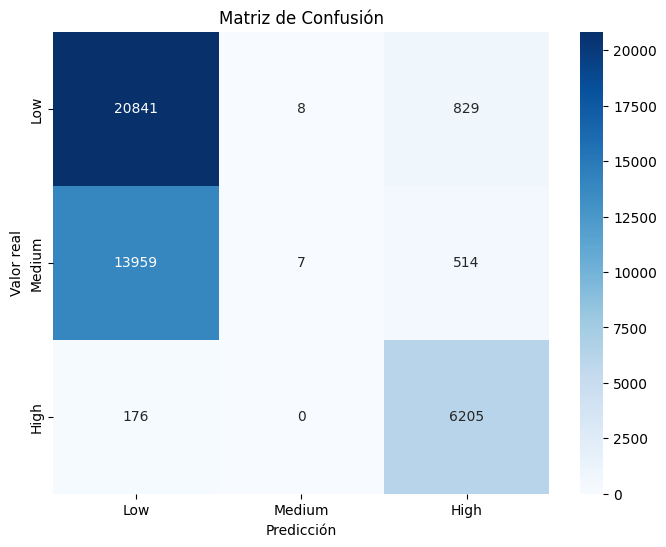


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.96      0.74     21678
      Medium       0.47      0.00      0.00     14480
        High       0.82      0.97      0.89      6381

    accuracy                           0.64     42539
   macro avg       0.63      0.64      0.54     42539
weighted avg       0.59      0.64      0.51     42539



{'Accuracy': 0.6359575918568843,
 'Precision (macro)': 0.6282014917479236,
 'Recall (macro)': 0.6447636562553323,
 'F1-score (macro)': 0.5425473195015923,
 'ROC-AUC': 0.7523107857613928}

In [13]:
evaluar_modelo(model_DT,X_test,y_test)

Podemos observar que DecisionTree por el desbalanceo, muestra scores muy separados entre la clase medium y las otras 2 clases, tambien podemos apreciar que los scores de High estan en un prefecto 1, ademas predice bien los high pero no predice los high como low o medium 

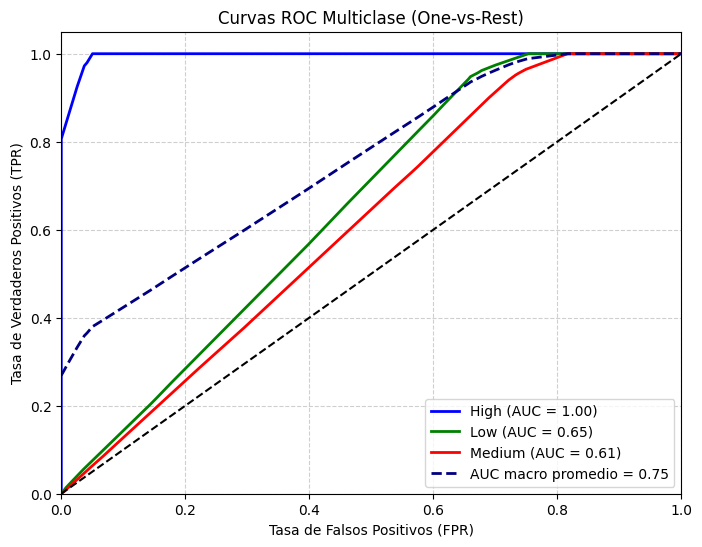


===== AUC por clase =====
High: 0.9958
Low: 0.6490
Medium: 0.6122
AUC macro promedio: 0.7523


({0: 0.9957756251470424, 1: 0.6489505413146797, 2: 0.6122061908224561},
 0.7523107857613927)

In [14]:
plot_roc_multiclass(model_DT,X_test,y_test)

Podemos observar que el AUC de High es perfecto 1, lo que puede ser señal de overffiting algo que es muy comun que ocurra con DecisionTree, Low y medium tienen 0.59 y 0.54 tienen mas dificultades de poder distinguir entre clases 

### Balanceo por SMOTE

In [15]:
pipe_DT_bal=crear_pipeline(DecisionTreeClassifier(random_state=0,max_depth=5,min_samples_leaf=3), tipo="balanceo_smote")

In [16]:
start=time.time()
model_bal=pipe_DT_bal.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.12 minutos


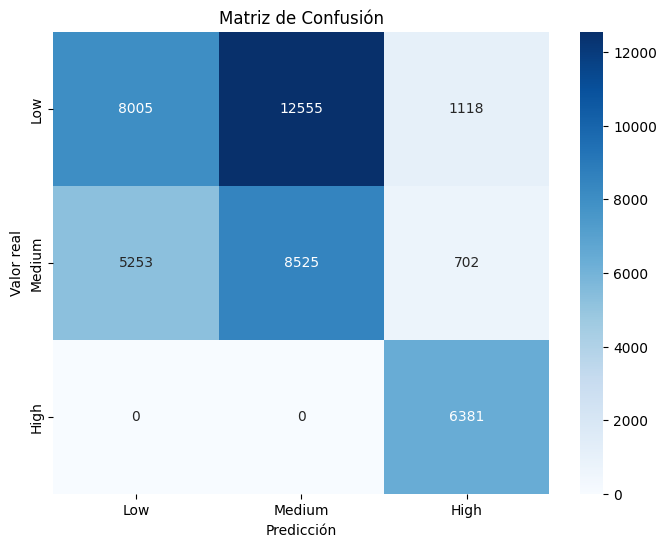


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.37      0.46     21678
      Medium       0.40      0.59      0.48     14480
        High       0.78      1.00      0.88      6381

    accuracy                           0.54     42539
   macro avg       0.60      0.65      0.60     42539
weighted avg       0.56      0.54      0.53     42539



{'Accuracy': 0.5385881191377324,
 'Precision (macro)': 0.5954246674120783,
 'Recall (macro)': 0.6526704922049275,
 'F1-score (macro)': 0.6043088164316794,
 'ROC-AUC': 0.7556411825018506}

In [17]:
evaluar_modelo(model_bal,X_test,y_test)

Podemos observar que las metricas despues del balanceo no cambiaron demasiado con respecto a lo anterior, aqune el recall de Low aumento en comparacion a como estaba antes

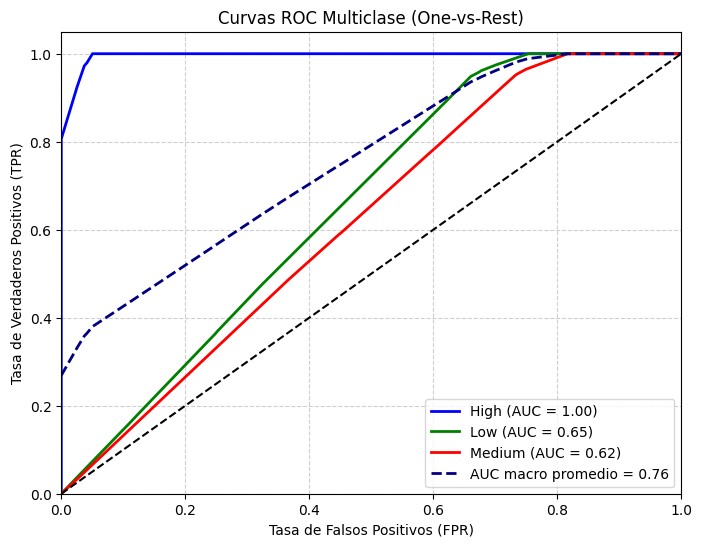


===== AUC por clase =====
High: 0.9958
Low: 0.6537
Medium: 0.6175
AUC macro promedio: 0.7556


({0: 0.9957756251470424, 1: 0.6536796963690343, 2: 0.6174682259894749},
 0.7556411825018504)

In [18]:
plot_roc_multiclass(model_bal,X_test,y_test)

Los ROC no cambiaron despues de realizar el balanceo por SMOTE, con High en perfecto 1 y los otros 2 con 0.59 y 0.55

### Balanceo por ADASYN

In [19]:
pipe_DT_ads=crear_pipeline(DecisionTreeClassifier(random_state=0,max_depth=5,min_samples_leaf=3), tipo="balanceo_adasyn")

In [20]:
start=time.time()
model_ads=pipe_DT_ads.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.28 minutos


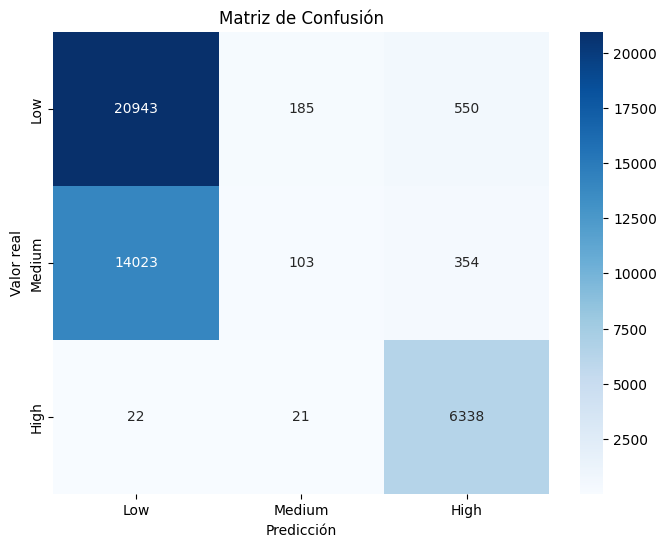


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.97      0.74     21678
      Medium       0.33      0.01      0.01     14480
        High       0.88      0.99      0.93      6381

    accuracy                           0.64     42539
   macro avg       0.60      0.66      0.56     42539
weighted avg       0.55      0.64      0.52     42539



{'Accuracy': 0.6437386868520651,
 'Precision (macro)': 0.6023608641464648,
 'Recall (macro)': 0.6554897207221265,
 'F1-score (macro)': 0.5611959608780178,
 'ROC-AUC': 0.7548638607470203}

In [21]:
evaluar_modelo(model_ads,X_test,y_test)

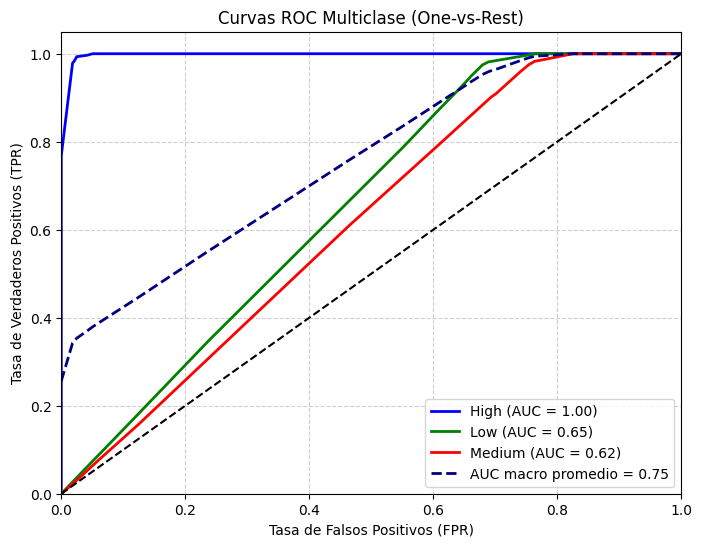


===== AUC por clase =====
High: 0.9975
Low: 0.6519
Medium: 0.6152
AUC macro promedio: 0.7549


({0: 0.9974982338003403, 1: 0.6519183774984738, 2: 0.6151749709422469},
 0.7548638607470205)

In [22]:
plot_roc_multiclass(model_ads,X_test,y_test)

## Balanceo por classweight

In [23]:
pipe_DT_cw=crear_pipeline(DecisionTreeClassifier(random_state=0,class_weight='balanced',max_depth=5,min_samples_leaf=3), tipo="normal")

In [24]:
start=time.time()
model_cw=pipe_DT_cw.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.01 minutos


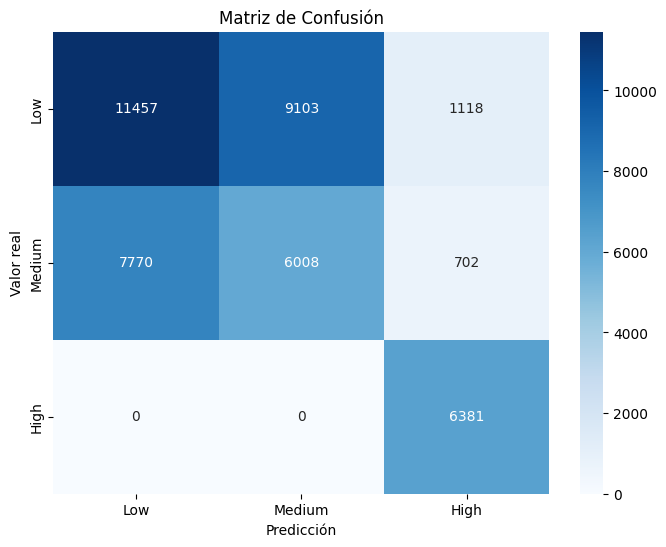


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.53      0.56     21678
      Medium       0.40      0.41      0.41     14480
        High       0.78      1.00      0.88      6381

    accuracy                           0.56     42539
   macro avg       0.59      0.65      0.61     42539
weighted avg       0.56      0.56      0.55     42539



{'Accuracy': 0.5605679494111286,
 'Precision (macro)': 0.5905159319343651,
 'Recall (macro)': 0.6478084306772302,
 'F1-score (macro)': 0.6138113397566398,
 'ROC-AUC': 0.7526461464565655}

In [25]:
evaluar_modelo(model_cw,X_test,y_test)

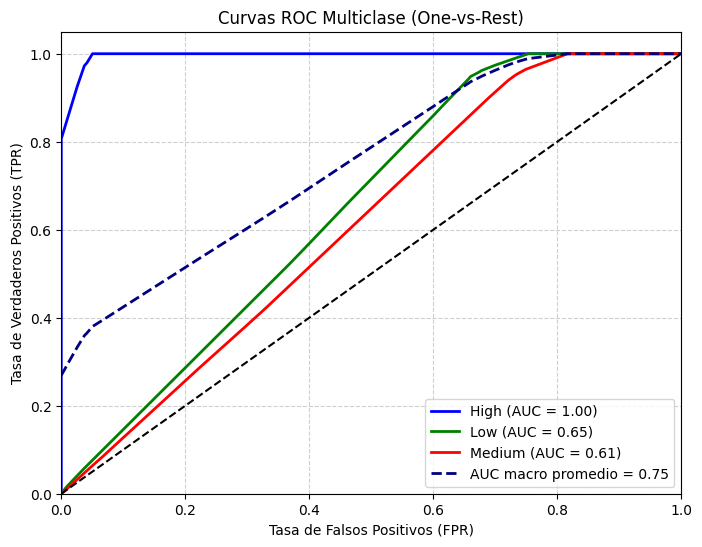


===== AUC por clase =====
High: 0.9958
Low: 0.6494
Medium: 0.6127
AUC macro promedio: 0.7526


({0: 0.9957756251470424, 1: 0.6494274922028926, 2: 0.6127353220197614},
 0.7526461464565655)

In [26]:
plot_roc_multiclass(model_cw,X_test,y_test)

## Tabla comparativa
| DecisionTree      | Accuracy | Precision_macro | Recall_macro | F1-macro | AUC  | Tiempo en minutos
|---------------|----------|----------|--------|----------|------|------|
| Benchmark      | 0.64     | 0.50     | 0.64   | 0.56    | 0.75 | 0.07
| SMOTE     | 0.62    | 0.62     | 0.63   | 0.58     | 0.75 | 0.33
| ADASYN     | 0.62    | 0.55     | 0.63   | 0.52     | 0.75 |1.00
| class_weight     | 0.57    | 0.63     | 0.64   | 0.63     | 0.75 | 0.08 

El mejor modelo de DecisionTree es el de class weight balanced